# Gene regulatory network: testing preservation after WGAN generation

1. Upload and summarize the data: single-cell RNA sequences.
2. Visualize the data after dimensionality reduction (UMAP).
3. Perform graphical lasso analysis.
4. Generate synthetic data via Wasserstein-GAN.
5. Compare visualization after UMAP reduction and Graphical lasso results for synthetic and real data.
6. Include an additional term that penalizes difference in Graphical lasso in the loss function - generate synthetic data using this approach.
7. Compare visualization after UMAP reduction and Graphical lasso results for two types of synthetic data (with and without the modified loss function) and real data.

Dataset used is compiled from 4 publicly available datasets under the GEO accessions: GSE90848 (Yang, mouse hair follicle subpopulations), GSE67602 (Joost, mouse epidermal cells), GSE99989 (Ghahramani, in vitro mouse keratinocytes), GSE96772 (Buenrostro, human blood cells), and at the Short Read Archive under accession number SRP073767 (Zheng, human blood monocytes). The datasets were combined and normalized by authors of the paper "Generative adversarial networks simulate gene expression and predict perturbations in single cells" (https://www.biorxiv.org/content/10.1101/262501v2.full). The combined dataset is avilable at https://github.com/luslab/scRNAseq-WGAN-GP/tree/master/data.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from numpy import genfromtxt
from sklearn.preprocessing import MinMaxScaler

# dimensionality reduction
from sklearn.manifold import TSNE
# data preprocessing
from sklearn.preprocessing import StandardScaler

In [2]:
#input the data - gene expression - single-cell RNA sequences
input_ltpm_matrix = genfromtxt('four_datasets_combined_lTPM_red_small_clean.csv', delimiter=',', skip_header=1)

#Dataset exploration
Let us explore the dataset that represents a sincle-cell RNA sequencing. It is a matrix of the size (samples, genes), where the number of rows represents how many samples we have and the number of columns stands for the number of genes. Each column contains gene expressions for various cells.

In [3]:
#view the data matrix
print(input_ltpm_matrix)
print('the shape of the matrix is',input_ltpm_matrix.shape)
samples = input_ltpm_matrix.shape[0]
genes = input_ltpm_matrix.shape[1]
print('there are', samples, 'samples, each one with', genes, 'gene expressions.' )

[[5.78303899 0.         3.83285097 ... 3.66428068 0.         5.8855578 ]
 [6.23190783 0.         4.26113701 ... 5.6164097  0.         2.06658458]
 [0.         5.65199367 6.51193323 ... 0.         6.60993674 6.0078448 ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         3.45006442 0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         2.29609212]]
the shape of the matrix is (6605, 2263)
there are 6605 samples, each one with 2263 gene expressions.


Data preprocessing: let us rescale the data using Standard Scaler. Standard scaler is scaling features so that the mean equals 0 and variance equals 1, which is an important preprocessing step for the covariance analysis that we apply on the data. We will use a small subset of data first (500->1000 entry) and rescale the small dataset for better results.

In [4]:
X = input_ltpm_matrix
X_small = X[500:1000,:]
scaler = StandardScaler()
X_small_scaled = scaler.fit_transform(X_small)

Let us visualize the data matrix - as we can see it is a sparse matrix, where many values equal to zero (dark blue).

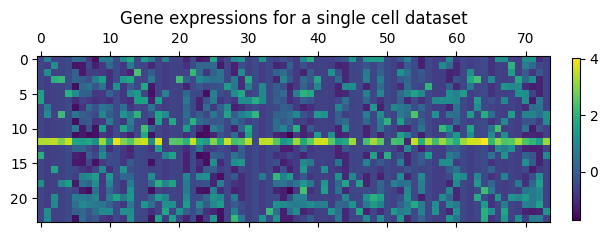

In [5]:
# visual representation of a part of the expression matrix:
fig, ax = plt.subplots(figsize=(7, 4))

#cax = ax.matshow(X[1:25, 1:75])
cax = ax.matshow(X_small_scaled[1:25, 1:75])
ax.set_title('Gene expressions for a single cell dataset')

fig.colorbar(cax, fraction=0.015, pad=0.04)

plt.show()

#Dimensionality reduction and visualization

Let us visualize the data using a dimensionality reduction UMAP. Reducing to two dimensions first.

In [ ]:
import umap

# create UMAP model
reducer = umap.UMAP(n_components=2, random_state=17)
#reducer = umap.UMAP(n_components = 2, random_state=None, n_jobs=-1) #faster, but no reproducibility (a bit of randomness)

# reduce dimensions
embedding = reducer.fit_transform(X_small_scaled)

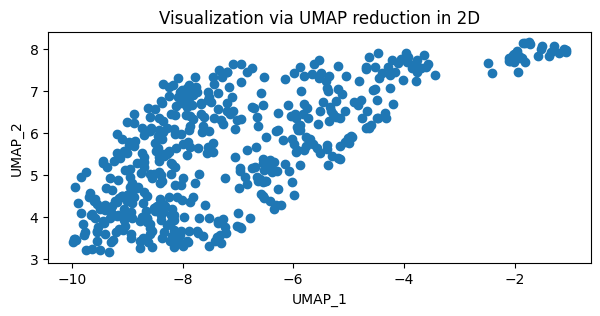

In [ ]:
# visualize the result of the embedding:
plt.figure(figsize=(7,3))
plt.title('Visualization via UMAP reduction in 2D')
plt.scatter(embedding[:,0], embedding[:,1])
plt.xlabel("UMAP_1")
plt.ylabel("UMAP_2")
plt.show()

Visualize small subeset of data in 3D using UMAP.

In [ ]:
# create UMAP model
#reducer = umap.UMAP(n_components=3, random_state=17) #reproducibility - a bit slower
reducer = umap.UMAP(n_components = 3, random_state=None, n_jobs=-1) #faster, but no reproducibility (a bit of randomness)

# reduce dimensions
embedding_3d = reducer.fit_transform(X_small_scaled)

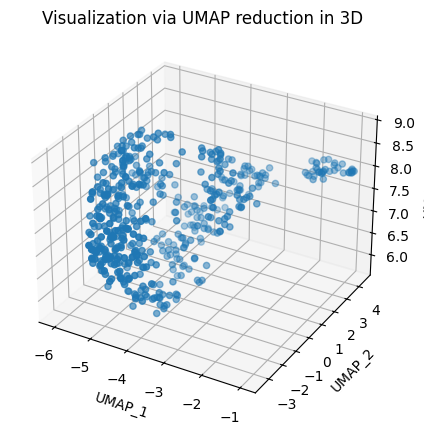

In [ ]:
# plot the result of a UMAP embedding:

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    embedding[:,0],
    embedding[:,1],
    embedding[:,2]
)

ax.set_title('Visualization via UMAP reduction in 3D')
ax.set_xlabel("UMAP_1")
ax.set_ylabel("UMAP_2")
ax.set_zlabel("UMAP_3")

plt.show()

# Graphical lasso

In [ ]:
import sklearn.covariance as skc

Function graphical lasso uses a matrix (n_features x n_features) of an empirical covariance to estimate covariance matrix. Therefore we need to compute the empirical covariance first and feed it to the GraphicalLasso function.

In [ ]:
empirical_covariance = np.cov(np.transpose(X_small_scaled)) # need to transpose here, because for np.cov each row represents a variable and each column represents an observation.

In [ ]:
np.diag(empirical_covariance)

array([1.00200401, 1.00200401, 1.00200401, ..., 1.00200401, 1.00200401,
       1.00200401])

In [ ]:
# let us check the dimensionality of the empirical covariance matrix
empirical_covariance.shape

(2263, 2263)

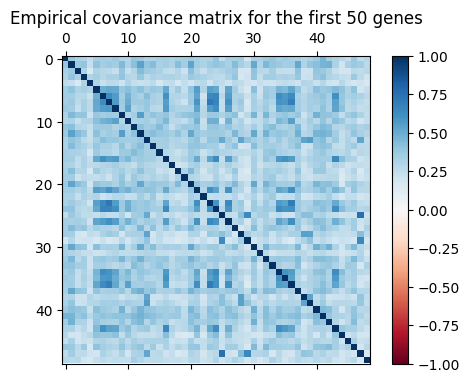

In [ ]:
# let us plot a submatrix of the first 50 genes out of empirical covariance matrix
fig, ax = plt.subplots(figsize=(7, 4))

cax = ax.matshow(empirical_covariance[1:50, 1:50],cmap='RdBu', vmin=-1, vmax=1)
ax.set_title('Empirical covariance matrix for the first 50 genes')

fig.colorbar(cax, fraction=0.03, pad=0.04)

plt.show()

Let us consider a submatrix of the empirical covariance - the first k rows and columns - this illustrates the realtionship between the first k genes. We use graphical lasso to estimate (using lasso optimization that encourages sparse matrices) the precision matrix.

In [ ]:
k = 50
submatrix_emp_cov = empirical_covariance[:k, :k]

In [ ]:
cov, precision = skc.graphical_lasso(submatrix_emp_cov, alpha = 0.5)

In [ ]:
#after running graphical lasso (which is an optimization procedure) we get a precision matrix as a result
#it is not a literal inverse of the empirical covariance matrix, but a result of an optimization procedure,
#where we favor the sparse output (many off diagonal entries equal to 0)
print(precision.shape)

(50, 50)


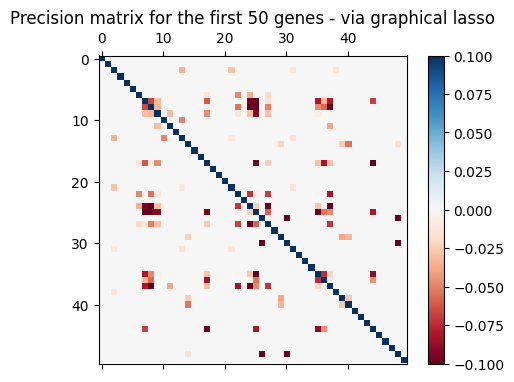

In [ ]:
# let us plot a submatrix of the first 50 genes out of the precision matrix
#plt.matshow(precision[1:50, 1:50])

fig, ax = plt.subplots(figsize=(7, 4))

cax = ax.matshow(precision[:50, :50],cmap='RdBu', vmin=-0.1, vmax=0.1)# focus on small off-diagonal entries
ax.set_title('Precision matrix for the first 50 genes - via graphical lasso')

fig.colorbar(cax, fraction=0.03, pad=0.04)

plt.show()

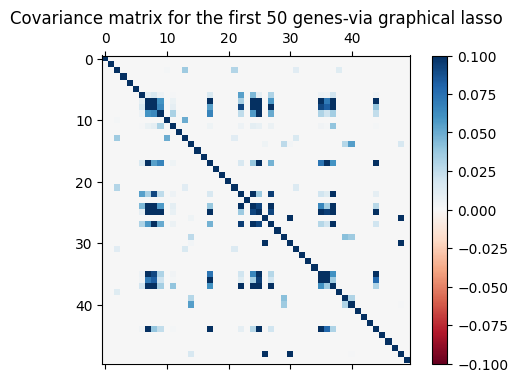

In [ ]:
#let us plt the covariance matrix as a result of the Lasso procedure
fig, ax = plt.subplots(figsize=(7, 4))

cax = ax.matshow(cov[:50, :50],cmap='RdBu', vmin=-0.1, vmax=0.1)
ax.set_title('Covariance matrix for the first 50 genes-via graphical lasso')

fig.colorbar(cax, fraction=0.03, pad=0.04)

plt.show()

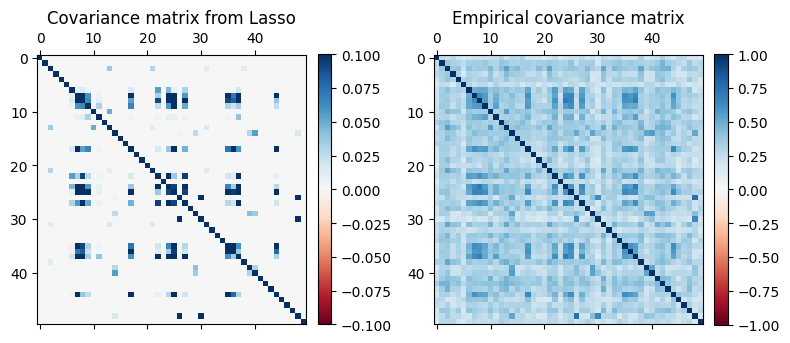

In [ ]:
#let us compare lasso covariance matrix to the empirical covariance matrix
#notice that the scale is different for the two matrices

# Create horizontal figure with 2 axes
fig, axes = plt.subplots(ncols=2, figsize=(8, 4))  # width x height

# First plot: covariance from lasso
v_corr=0.1
c1 = axes[0].matshow(cov[:50,:50], cmap='RdBu', vmin=-v_corr, vmax=v_corr)
axes[0].set_title("Covariance matrix from Lasso")
fig.colorbar(c1, ax=axes[0], fraction=0.046, pad=0.04)

# Second plot: empirical covariance based on standardized data
v_prec=1
c2 = axes[1].matshow(empirical_covariance[:50,:50], cmap='RdBu', vmin=-v_prec, vmax=v_prec)
axes[1].set_title("Empirical covariance matrix")
fig.colorbar(c2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

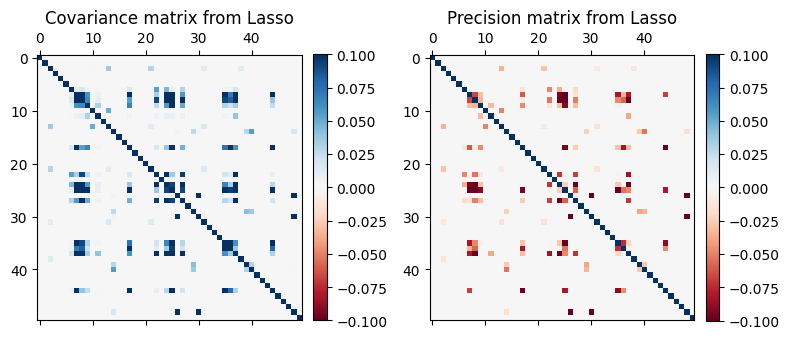

In [ ]:
#let us compare the precision matrix and the covariance matrix from lasso:
# Create horizontal figure with 2 axes
fig, axes = plt.subplots(ncols=2, figsize=(8, 4))  # width x height

# First plot: covariance from lasso
v_corr=0.1
c1 = axes[0].matshow(cov[:50,:50], cmap='RdBu', vmin=-v_corr, vmax=v_corr)
axes[0].set_title("Covariance matrix from Lasso")
fig.colorbar(c1, ax=axes[0], fraction=0.046, pad=0.04)

# Second plot: precision matrix from lasso
v_prec=0.1
c2 = axes[1].matshow(precision[:50,:50], cmap='RdBu', vmin=-v_prec, vmax=v_prec)
axes[1].set_title("Precision matrix from Lasso")
fig.colorbar(c2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Counting edges in the graph - non-zero entries from the precision matrix.

In [ ]:
# Graphical lasso produces a sparse matrix (due to l1 regularization)
# non-zero values stand for the edges in the graph between nodes that stand for genes
num_zeros = np.count_nonzero(precision == 0)
print(num_zeros,'zeros out of', k*k, 'entries')
print('that means that there are', int((k*k-num_zeros)/2), 'edges in the graph')

2290 zeros out of 2500 entries
that means that there are 105 edges in the graph


#Synthetic data generation via GAN

We use deep learning to generate synthetic gene expression data (via TensorFlow).

In [7]:
import tensorflow as tf
from tensorflow.keras import layers

In [8]:
# Hyperparameters
n_features = 50 # how many genes we want to generate
noise_dim = n_features
batch_size = 32
n_discriminator = 5
epochs = 2000
clip_value = 0.01
learning_rate = 0.00005
generator_inner_size = 100 # size of the inner layer of the generator
discriminator_inner_size = 32 # size of the inner layer of the discriminator

In [9]:
# Generator
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(noise_dim,)),

        layers.Dense(generator_inner_size),
        layers.LeakyReLU(negative_slope=0.2),

        layers.Dense(generator_inner_size),
        layers.LeakyReLU(negative_slope=0.2),

        layers.Dense((n_features))
    ])
    return model

In [10]:
# discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(n_features,)),

        layers.Dense(discriminator_inner_size),
        layers.LeakyReLU(negative_slope=0.2),

        layers.Dense(discriminator_inner_size),
        layers.LeakyReLU(negative_slope=0.2),

        layers.Dense(1)  # probability of data being real
    ])
    return model

In [11]:
G = build_generator()
D = build_discriminator()

In [12]:
# Optimizers
opt_G = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)
opt_D = tf.keras.optimizers.RMSprop(learning_rate=learning_rate)

In [ ]:
# Decide how many cells we want to generate, take a larger subset of data for training
num_cells_generate = 100
num_cells_train = 5*num_cells_generate
print(num_cells_train)

500


In [ ]:
# Restrict the features in the data to n_features=n_noise genes:
X_training = X[500:500+num_cells_train, :n_features]
#rescale the data using StandardScaler:
scaler = StandardScaler()
X_training = scaler.fit_transform(X_training)

In [ ]:
# Prepare the dataset for training (split it into small datasets of a batch_size size)
dataset = tf.data.Dataset.from_tensor_slices(X_training).shuffle(1000).batch(batch_size)

In [ ]:
# Training loop
for epoch in range(epochs): #we have 2000 epochs
    for real_batch in dataset:
        batch_size_actual = real_batch.shape[0]
        # update discriminator multiple times per generator update
        for _ in range(n_discriminator):
            # Sample noise
            z = tf.random.normal([batch_size_actual, noise_dim])
            with tf.GradientTape() as tape:
                fake_batch = G(z)
                loss_D = tf.reduce_mean(D(fake_batch)) - tf.reduce_mean(D(real_batch)) #Wasserstein_loss
            grads = tape.gradient(loss_D, D.trainable_variables)
            opt_D.apply_gradients(zip(grads, D.trainable_variables))

            # Weight clipping to enforce Lipschitz constraint
            for var in D.trainable_variables:
                var.assign(tf.clip_by_value(var, -clip_value, clip_value))

        # Generator update - once per iteration
        z = tf.random.normal([batch_size_actual, noise_dim])
        with tf.GradientTape() as tape:
            fake_batch = G(z)
            loss_G = -tf.reduce_mean(D(fake_batch))
        grads = tape.gradient(loss_G, G.trainable_variables) #compute gradients and update generator
        opt_G.apply_gradients(zip(grads, G.trainable_variables))

    if epoch % 200 == 0: # print losses once in 200 epochs
        print(f"Epoch {epoch}, loss_D={loss_D.numpy():.4f}, loss_G={loss_G.numpy():.4f}")

Epoch 0, loss_D=-0.0002, loss_G=0.0001
Epoch 200, loss_D=-0.0017, loss_G=-0.0005
Epoch 400, loss_D=-0.0054, loss_G=0.0006
Epoch 600, loss_D=-0.0028, loss_G=0.0001
Epoch 800, loss_D=-0.0005, loss_G=0.0005
Epoch 1000, loss_D=-0.0009, loss_G=-0.0013
Epoch 1200, loss_D=-0.0011, loss_G=-0.0007
Epoch 1400, loss_D=-0.0010, loss_G=-0.0012
Epoch 1600, loss_D=-0.0014, loss_G=-0.0005
Epoch 1800, loss_D=-0.0016, loss_G=-0.0006


In [ ]:
#save the trained models
G.save("generator_model.keras")
D.save("discriminator_model.keras")

In [ ]:
# Generate synthetic data
z = tf.random.normal([100, noise_dim])
synthetic_data = G(z).numpy()
print(synthetic_data.shape)  # (100, n_features)

(100, 50)


In [ ]:
#save the generated data
np.savetxt('synthetic_data', synthetic_data)

# Comparison of the synthetic data to real data

In [6]:
#load synthetic data from the previous section
synthetic_data = np.loadtxt('synthetic_data')
#standardize the data:
scaler = StandardScaler()
synthetic_data_scaled = scaler.fit_transform(synthetic_data)

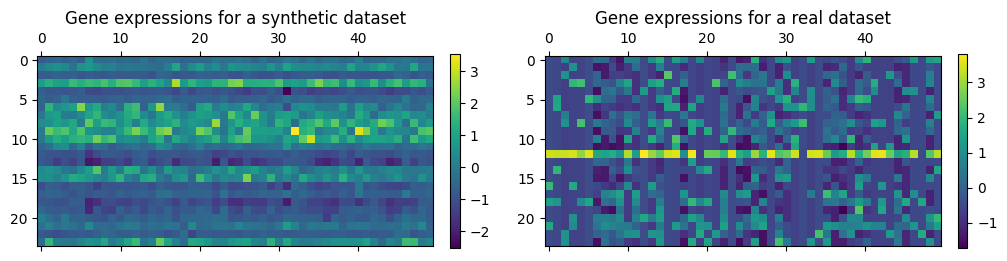

In [ ]:
# visual representation of a part of the expression matrix:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

cax1 = ax[0].matshow(synthetic_data_scaled[1:25, :])
ax[0].set_title('Gene expressions for a synthetic dataset')

cax2 = ax[1].matshow(X_small_scaled[1:25, :50])
ax[1].set_title('Gene expressions for a real dataset')

# Colorbars (one per plot)
fig.colorbar(cax1, ax=ax[0], fraction=0.023, pad=0.04)
fig.colorbar(cax2, ax=ax[1], fraction=0.023, pad=0.04)

plt.show()

In [ ]:
# compute a UMAP embedding in 2D for the synthetic data:
reducer = umap.UMAP(n_components=2, random_state=17)
embedding_synthetic = reducer.fit_transform(synthetic_data_scaled)

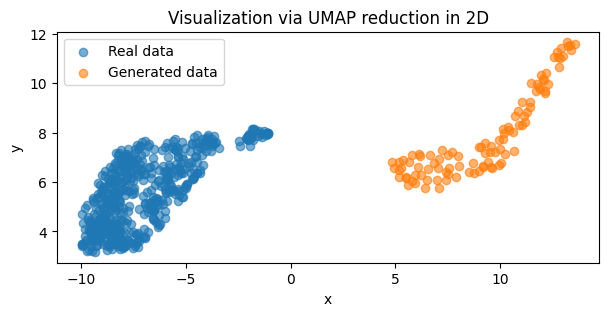

In [ ]:
#visualize the data using UMAP reduction in 2D - plot the synthetic data in orange, real data in blue:
plt.figure(figsize=(7,3))
plt.title('Visualization via UMAP reduction in 2D')
plt.scatter(embedding[:, 0], embedding[:, 1], label='Real data', alpha=0.6)
plt.scatter(embedding_synthetic[:, 0], embedding_synthetic[:, 1], label='Generated data', alpha=0.6)

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
#Graphical lasso for the synthetic data:
import sklearn.covariance as skc
empirical_covariance_synthetic = np.cov(np.transpose(synthetic_data_scaled))
cov_synthetic, precision_synthetic = skc.graphical_lasso(empirical_covariance_synthetic, alpha = 0.5)

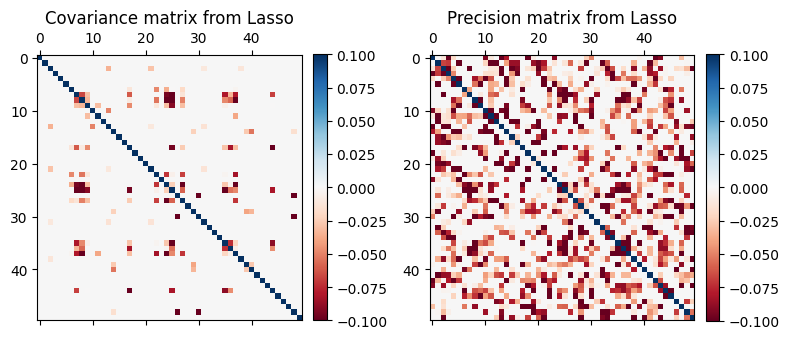

In [ ]:
#let us compare the precision matrix and the covariance matrix from lasso:
# Create horizontal figure with 2 axes
fig, axes = plt.subplots(ncols=2, figsize=(8, 4))  # width x height

# First plot: covariance from lasso
v_corr=0.1
c1 = axes[0].matshow(precision[:50,:50], cmap='RdBu', vmin=-v_corr, vmax=v_corr)
axes[0].set_title("Precision matrix for the real data")
fig.colorbar(c1, ax=axes[0], fraction=0.046, pad=0.04)

# Second plot: precision matrix from lasso
v_prec=0.1
c2 = axes[1].matshow(precision_synthetic[:50,:50], cmap='RdBu', vmin=-v_prec, vmax=v_prec)
axes[1].set_title("Precision matrix for the synthetic data")
fig.colorbar(c2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Adding a term that corrects with respect to the Graphical lasso to the loss function

Let us modify the learning process in three ways:
1. Add more training data.
2. Noise in the form of N(0, data_max/10)+Pois(1).
3. Add a Graphical lasso term to the loss function of the discriminator.

In [13]:
import tensorflow as tf
#tf.config.run_functions_eagerly(True)

In [14]:
#setting up the parameters and the dataset:
num_cells_generate = 100
num_cells_train = 2500
X_training = X[500:500+num_cells_train, :n_features]
#rescale the data using StandardScaler:
scaler = StandardScaler()
X_training = scaler.fit_transform(X_training)

In [15]:
# Prepare the dataset for training (split it into small datasets of a batch_size size)
dataset = tf.data.Dataset.from_tensor_slices(X_training).shuffle(1000).batch(batch_size)

In [17]:
for epoch in range(epochs):
    for real_batch in dataset:
        batch_size_actual = real_batch.shape[0]

        # Precompute once per batch
        real_batch = tf.cast(real_batch, tf.float32)
        max_data = tf.reduce_max(real_batch)
        max_data = tf.cast(max_data, tf.float32)

        # Covariance of real batch (once)
        cov_real = tf.matmul(real_batch, real_batch, transpose_a=True) / tf.cast(batch_size_actual, tf.float32)

        # Precompute Poisson noise for discriminator updates
        z_pois_base = tf.random.poisson(lam=1.0, shape=[batch_size_actual, noise_dim], dtype=tf.float32)

        # Discriminator updates
        for _ in range(n_discriminator):
            z_normal = (max_data / 10.0) * tf.random.normal([batch_size_actual, noise_dim])
            z = z_normal + z_pois_base  # reuse Poisson noise

            with tf.GradientTape() as tape:
                fake_batch = G(z)
                # cov_fake and loss
                cov_fake = tf.matmul(fake_batch, fake_batch, transpose_a=True) / tf.cast(batch_size_actual, tf.float32)
                loss_D = tf.reduce_mean(D(fake_batch)) - tf.reduce_mean(D(real_batch))
                alpha_lasso = 0.0001
                loss_D += alpha_lasso * tf.reduce_mean(tf.square(cov_fake - cov_real))

            grads = tape.gradient(loss_D, D.trainable_variables)
            opt_D.apply_gradients(zip(grads, D.trainable_variables))

            # Vectorized weight clipping
            D.set_weights([tf.clip_by_value(w, -clip_value, clip_value) for w in D.get_weights()])

        # Generator update (once per batch)
        z_normal = (max_data / 10.0) * tf.random.normal([batch_size_actual, noise_dim])
        z = z_normal + tf.random.poisson(lam=1.0, shape=[batch_size_actual, noise_dim], dtype=tf.float32)

        with tf.GradientTape() as tape:
            fake_batch = G(z)
            loss_G = -tf.reduce_mean(D(fake_batch))

        grads = tape.gradient(loss_G, G.trainable_variables)
        opt_G.apply_gradients(zip(grads, G.trainable_variables))

    # Print occasionally
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, loss_D={loss_D.numpy():.4f}, loss_G={loss_G.numpy():.4f}")

G.save("generator_model_modified_loss.keras")      # Keras native format
D.save("discriminator_model_modified_loss.keras")

Epoch 0, loss_D=-0.0024, loss_G=0.0024
Epoch 200, loss_D=-0.0033, loss_G=-0.0011
Epoch 400, loss_D=-0.0005, loss_G=-0.0002
Epoch 600, loss_D=-0.0012, loss_G=-0.0001
Epoch 800, loss_D=0.0002, loss_G=0.0002
Epoch 1000, loss_D=0.0001, loss_G=-0.0014
Epoch 1200, loss_D=0.0000, loss_G=-0.0010
Epoch 1400, loss_D=-0.0001, loss_G=0.0003
Epoch 1600, loss_D=-0.0003, loss_G=-0.0014
Epoch 1800, loss_D=0.0007, loss_G=-0.0013


In [19]:
tf.reduce_max(X_small_scaled)
max_data = tf.cast(max_data, tf.float32)
z = tf.random.normal([100, noise_dim])/max_data+tf.random.poisson(lam=1.0, shape=[100, noise_dim], dtype=tf.float32)
synthetic_data_modified = G(z).numpy()
print(synthetic_data_modified.shape)  # (100, n_features)

(100, 50)


In [21]:
np.savetxt('synthetic_data_modified_loss', synthetic_data_modified)

# Comparison of the two synthetic datasets and the real dataset.

In [9]:
#load synthetic data from the previous section
synthetic_data_modified = np.loadtxt('synthetic_data_modified_loss')
#standardize the data:
scaler = StandardScaler()
synthetic_data_modified_scaled = scaler.fit_transform(synthetic_data_modified)

Visual comparison of the single-cell RNA sequences.

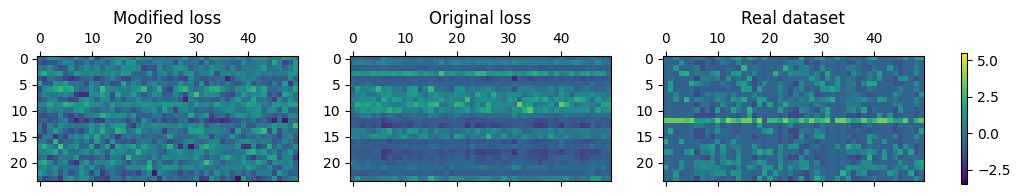

In [17]:
# Compute global min/max for consistent color scale
vmin = min(synthetic_data_modified_scaled.min(), synthetic_data_scaled.min(), X_small_scaled.min())
vmax = max(synthetic_data_modified_scaled.max(), synthetic_data_scaled.max(), X_small_scaled.max())

fig, ax = plt.subplots(1, 3, figsize=(12, 4))

# Use same vmin/vmax in both plots
cax1 = ax[0].matshow(synthetic_data_modified_scaled[1:25, :], vmin=vmin, vmax=vmax)
ax[0].set_title('Modified loss')

cax2 = ax[1].matshow(synthetic_data_scaled[1:25, :50], vmin=vmin, vmax=vmax)
ax[1].set_title('Original loss')

cax3 = ax[2].matshow(X_small_scaled[1:25, :50], vmin=vmin, vmax=vmax)
ax[2].set_title('Real dataset')

# Single shared colorbar
fig.colorbar(cax1, ax=ax, fraction=0.007, pad=0.04)

plt.show()

UMAP reduction comparison.

In [ ]:
import umap

# create UMAP model
reducer = umap.UMAP(n_components=2, random_state=17)
#reducer = umap.UMAP(n_components = 2, random_state=None, n_jobs=-1) #faster, but no reproducibility (a bit of randomness)

# reduce dimensions (from 50)
embedding = reducer.fit_transform(X_small_scaled[:,:50])
embedding_synthetic = reducer.fit_transform(synthetic_data_scaled)
embedding_modified = reducer.fit_transform(synthetic_data_modified_scaled)

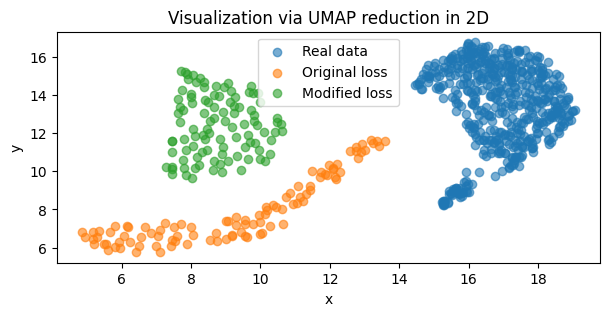

In [21]:
#visualize the data using UMAP reduction in 2D - plot the synthetic data in a different color:
plt.figure(figsize=(7,3))
plt.title('Visualization via UMAP reduction in 2D')
plt.scatter(embedding[:, 0], embedding[:, 1], label='Real data', alpha=0.6)
plt.scatter(embedding_synthetic[:, 0], embedding_synthetic[:, 1], label='Original loss', alpha=0.6)
plt.scatter(embedding_modified[:, 0], embedding_modified[:, 1], label='Modified loss', alpha=0.6)

plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()

Graphical lasso comparison.

In [ ]:
import sklearn.covariance as skc

#apply Graphical lasso:

empirical_covariance = np.cov(np.transpose(X_small_scaled[:,:50]))
cov, precision = skc.graphical_lasso(empirical_covariance, alpha = 0.5)
empirical_covariance_synthetic = np.cov(np.transpose(synthetic_data_scaled))
cov_synthetic, precision_synthetic = skc.graphical_lasso(empirical_covariance_synthetic, alpha = 0.5)
empirical_covariance_modified = np.cov(np.transpose(synthetic_data_modified_scaled))
cov_modified, precision_modified = skc.graphical_lasso(empirical_covariance_modified, alpha = 0.5)

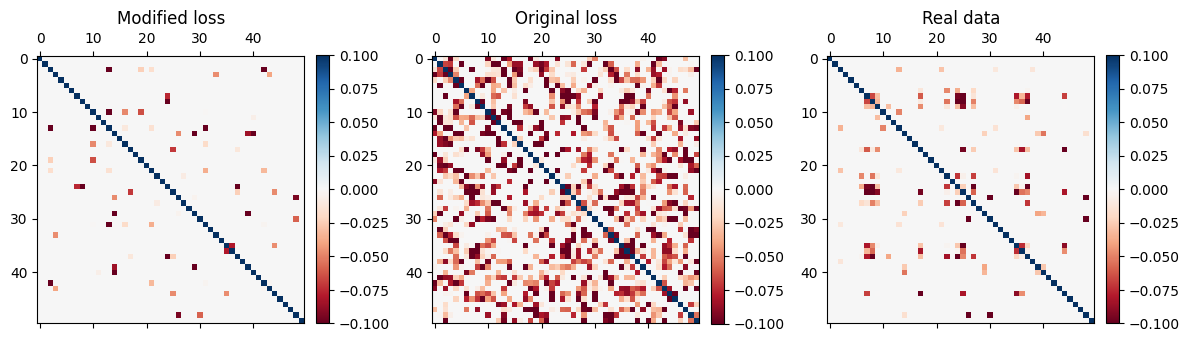

In [27]:
#let us compare the precision matrix and the covariance matrix from lasso:
# Create horizontal figure with 2 axes
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))  # width x height
v_prec=0.1
# Synthetic data - original loss

c1 = axes[0].matshow(precision_modified, cmap='RdBu', vmin=-v_prec, vmax=v_prec)
axes[0].set_title("Modified loss")
fig.colorbar(c1, ax=axes[0], fraction=0.046, pad=0.04)

# Synthetic data - modified loss

c2 = axes[1].matshow(precision_synthetic, cmap='RdBu', vmin=-v_prec, vmax=v_prec)
axes[1].set_title("Original loss")
fig.colorbar(c2, ax=axes[1], fraction=0.046, pad=0.04)

# Real data

c3 = axes[2].matshow(precision, cmap='RdBu', vmin=-v_prec, vmax=v_prec)
axes[2].set_title("Real data")
fig.colorbar(c3, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()